In [20]:
pip install tensorflow-gpu

  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [41]:
# importing important libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [42]:
# 1. Load dataset
file_path = "/content/household_power_consumption.txt"
df = pd.read_csv(file_path, sep=';', low_memory=False, na_values='?')

In [43]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [44]:
# 2. Combine Date and Time into datetime
df['DateTime'] = df['Date'].str.strip() + ' ' + df['Time'].str.strip()  # remove extra spaces

# Convert to datetime (errors='coerce' ensures bad values become NaT)
df['DateTime'] = pd.to_datetime(df['DateTime'], format='%d/%m/%Y %H:%M:%S', errors='coerce')

# Drop rows where datetime conversion failed
df = df.dropna(subset=['DateTime'])

df.drop(['Date', 'Time'], axis=1, inplace=True)

In [45]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [46]:
df.dtypes

,0
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64
DateTime,datetime64[ns]


In [47]:
# Convert all other columns to numeric
for col in df.columns:
    if col not in ['DateTime']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [48]:
# Drop rows with any NaN values
df.dropna(inplace=True)

In [49]:
df.shape

(2049280, 8)

In [50]:
# Drop duplicates and irrelevant column
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (2049280, 8)


In [51]:
# 5. Feature Engineering: Extract hour, day, month
df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day
df['Month'] = df['DateTime'].dt.month
df.drop('DateTime', axis=1, inplace=True)

In [52]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day,Month
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,16,12
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,16,12
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,16,12
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,16,12
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,16,12


In [53]:
# 6. Define inputs and target
X = df.drop('Global_active_power', axis=1)
y = df['Global_active_power']

In [54]:
# 7. Normalize features

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [56]:
# 8. Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [59]:
#Initializing ANN

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))  # Regression → linear activation


# Compile
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train model with early stopping
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=512,
    callbacks=[early_stop]
)

Epoch 1/50
2562/2562 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.1428 - mae: 0.1421 - val_loss: 0.0013 - val_mae: 0.0224
Epoch 2/50
2562/2562 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0014 - mae: 0.0238 - val_loss: 0.0012 - val_mae: 0.0210
Epoch 3/50
2562/2562 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0013 - mae: 0.0232 - val_loss: 0.0012 - val_mae: 0.0225
Epoch 4/50
2562/2562 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0012 - mae: 0.0225 - val_loss: 0.0011 - val_mae: 0.0219
Epoch 5/50
2562/2562 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0012 - mae: 0.0220 - val_loss: 0.0012 - val_mae: 0.0229
Epoch 6/50
2562/2562 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0012 - mae: 0.0218 - val_loss: 0.0011 - val_mae: 0.0222
Epoch 7/50
2562/2562 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0011 - mae: 0.0213 - val_loss: 0.0011 - val_mae: 0.0204
Epoch 8/50
2562/2562 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0011 - mae: 0.0213 - val_loss: 0.0010 - val_mae: 0.0206
Epoch 9/50
2562/2562 ━━━━━━━━━━━━━━━━━━

In [63]:
# Evaluate with model.evaluate
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MSE: {loss:.4f}")
print(f"Test MAE: {mae:.4f}")


12808/12808 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 9.1822e-04 - mae: 0.0187
Test MSE: 0.0009
Test MAE: 0.0187


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict
y_pred = model.predict(X_test)

# Compute metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


12808/12808 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step
Mean Absolute Error (MAE): 0.0187
Mean Squared Error (MSE): 0.0009
Root Mean Squared Error (RMSE): 0.0304
R² Score: 0.9992


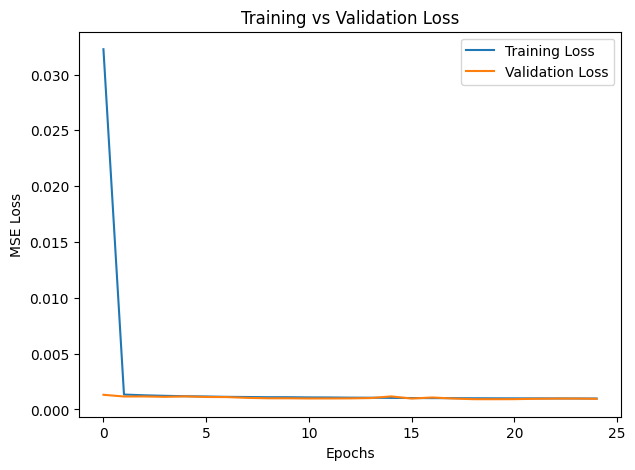

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


12808/12808 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


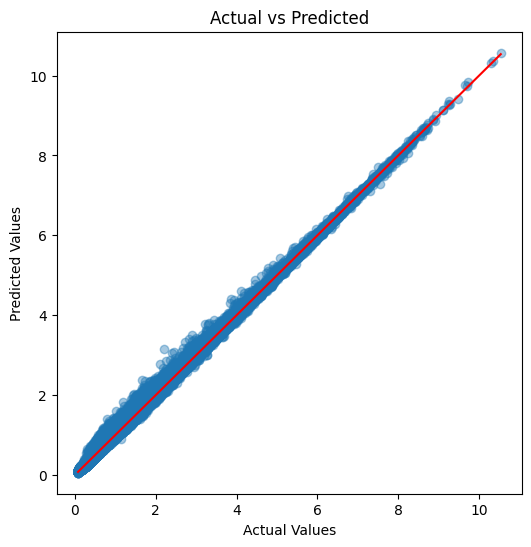

In [68]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')  # perfect-fit line
plt.show()
